# Versao 13 - Classificacao Multiclasse Com BiGRU + MHA

Este e o notebook central da `versao13`. Aqui treinamos o modelo `BiGRU + Multi-Head Self-Attention` sobre `X_seq_bigru`, mantendo o mesmo protocolo de avaliacao das versoes recentes.


## Hipotese experimental imediata

Se a simplificacao arquitetural fizer sentido, a `versao13` pode recuperar parte do desempenho das melhores redes recorrentes do projeto com um desenho mais direto do que a `versao12`.


In [1]:
from pathlib import Path
import importlib
import sys

import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd()
PROJECT_ROOT = ROOT.parent if ROOT.name == 'versao13' else ROOT
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import versao13.pipeline_v13 as pipeline_v13

pipeline_v13 = importlib.reload(pipeline_v13)
evaluate_predictions = pipeline_v13.evaluate_predictions
export_evaluation_artifacts = pipeline_v13.export_evaluation_artifacts
load_bigru_attention_model = pipeline_v13.load_bigru_attention_model
load_bundle = pipeline_v13.load_bundle
load_split_arrays = pipeline_v13.load_split_arrays
plot_confusion_matrix_for_predictions = pipeline_v13.plot_confusion_matrix_for_predictions
predict_bigru_attention_model_classes = pipeline_v13.predict_bigru_attention_model_classes
prepare_classification_artifacts = pipeline_v13.prepare_classification_artifacts
train_bigru_attention_model = pipeline_v13.train_bigru_attention_model

RUN_NAME = 'classificacao_v13_bigru_mha'
RUN_DIR = PROJECT_ROOT / 'artifacts' / 'reports_v13' / RUN_NAME
MODEL_DIR = RUN_DIR / 'bigru_mha'
DATASET_ROOT = PROJECT_ROOT / '3W' / 'dataset'

if not (RUN_DIR / 'bundle_v13.json').exists():
    prepare_classification_artifacts(
        dataset_root=DATASET_ROOT,
        run_name=RUN_NAME,
        random_state=42,
        sequence_length=180,
    )



In [2]:
bundle = load_bundle(RUN_DIR / 'bundle_v13.json')
train_arrays = load_split_arrays(RUN_DIR / 'train_arrays.npz')
validation_arrays = load_split_arrays(RUN_DIR / 'validation_arrays.npz')
test_arrays = load_split_arrays(RUN_DIR / 'test_arrays.npz')

print('X_seq original:', train_arrays['X_seq'].shape)
print('X_seq_bigru:', train_arrays['X_seq_bigru'].shape)



X_seq original: (1559, 180, 18)
X_seq_bigru: (1559, 180, 1)


In [3]:
training_summary = train_bigru_attention_model(
    X_train_seq=train_arrays['X_seq_bigru'],
    y_train=train_arrays['y'],
    X_val_seq=validation_arrays['X_seq_bigru'],
    y_val=validation_arrays['y'],
    output_dir=MODEL_DIR,
    class_labels=bundle.class_labels,
    hidden_size=48,
    num_layers=1,
    attention_heads=8,
    dropout=0.30,
    learning_rate=1e-3,
    weight_decay=1e-4,
    batch_size=32,
    epochs=30,
    patience=8,
    random_state=42,
)

training_summary



TrainingSummary(model_name='bigru_multihead_attention_model', checkpoint_path='/home/tiagoriosrocha/Desktop/lstm-w3/artifacts/reports_v13/classificacao_v13_bigru_mha/bigru_mha/bigru_mha_best.pt', config_path='/home/tiagoriosrocha/Desktop/lstm-w3/artifacts/reports_v13/classificacao_v13_bigru_mha/bigru_mha/bigru_mha_config.json', history_path='/home/tiagoriosrocha/Desktop/lstm-w3/artifacts/reports_v13/classificacao_v13_bigru_mha/bigru_mha/bigru_mha_history.csv', best_epoch=17, best_val_macro_f1=0.39180531948344405, best_val_accuracy=0.37425149700598803, best_val_balanced_accuracy=0.5126005140545437)

In [4]:
best_model = load_bigru_attention_model(training_summary.config_path)

validation_pred = predict_bigru_attention_model_classes(
    best_model,
    validation_arrays['X_seq_bigru'],
)
test_pred = predict_bigru_attention_model_classes(
    best_model,
    test_arrays['X_seq_bigru'],
)

validation_eval = evaluate_predictions(
    validation_arrays['y'],
    validation_pred,
    class_labels=bundle.class_labels,
)
test_eval = evaluate_predictions(
    test_arrays['y'],
    test_pred,
    class_labels=bundle.class_labels,
)

export_evaluation_artifacts(validation_eval, MODEL_DIR, 'bigru_validation')
export_evaluation_artifacts(test_eval, MODEL_DIR, 'bigru_test')

pd.DataFrame(
    [
        {
            'split': 'validation',
            'accuracy': validation_eval['accuracy'],
            'macro_f1': validation_eval['macro_f1'],
            'balanced_accuracy': validation_eval['balanced_accuracy'],
        },
        {
            'split': 'test',
            'accuracy': test_eval['accuracy'],
            'macro_f1': test_eval['macro_f1'],
            'balanced_accuracy': test_eval['balanced_accuracy'],
        },
    ]
)



,split,accuracy,macro_f1,balanced_accuracy
0,validation,0.374251,0.391805,0.512601
1,test,0.379104,0.381683,0.548232


,epoch,learning_rate,train_loss,train_accuracy,train_macro_f1,train_balanced_accuracy,val_accuracy,val_macro_f1,val_balanced_accuracy
20,21,0.0010,0.804587,0.302758,0.323462,0.548386,0.299401,0.324605,0.504428
21,22,0.0010,0.923625,0.344452,0.370235,0.569283,0.341317,0.364536,0.531261
22,23,0.0005,0.796912,0.339320,0.380573,0.557772,0.353293,0.386051,0.538522
23,24,0.0005,0.744561,0.304041,0.347063,0.543061,0.323353,0.364699,0.550026
24,25,0.0005,0.712379,0.286081,0.325402,0.528211,0.260479,0.295723,0.463570


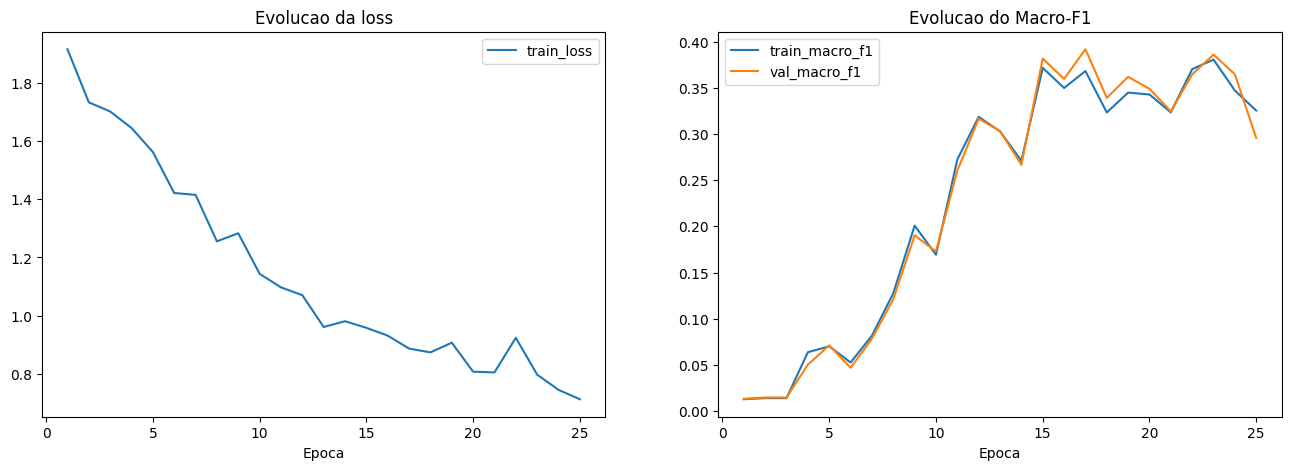

In [5]:
history = pd.read_csv(training_summary.history_path)
display(history.tail())

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].plot(history['epoch'], history['train_loss'], label='train_loss')
axes[0].set_title('Evolucao da loss')
axes[0].set_xlabel('Epoca')
axes[0].legend()

axes[1].plot(history['epoch'], history['train_macro_f1'], label='train_macro_f1')
axes[1].plot(history['epoch'], history['val_macro_f1'], label='val_macro_f1')
axes[1].set_title('Evolucao do Macro-F1')
axes[1].set_xlabel('Epoca')
axes[1].legend()
plt.show()



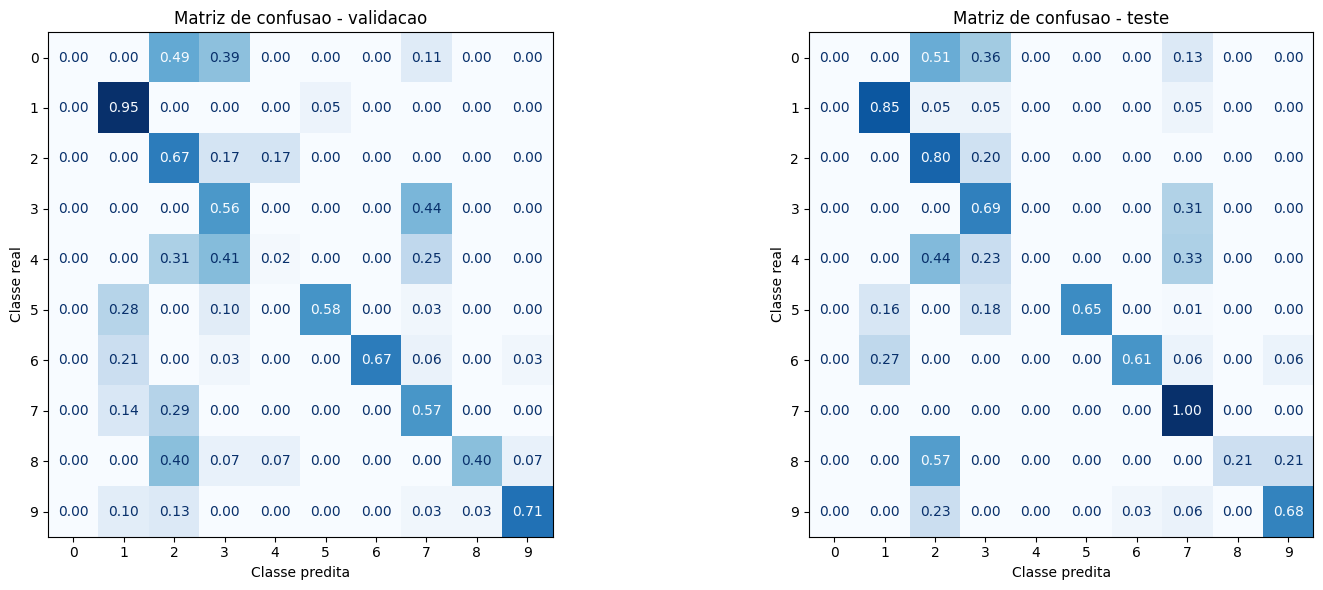

,label,precision,recall,f1-score,support
0,0,0.000000,0.000000,0.000000,89.000000
1,1,0.459459,0.850000,0.596491,20.000000
2,2,0.045455,0.800000,0.086022,5.000000
3,3,0.159420,0.687500,0.258824,16.000000
4,4,0.000000,0.000000,0.000000,52.000000
5,5,1.000000,0.647059,0.785714,68.000000
6,6,0.952381,0.606061,0.740741,33.000000
7,7,0.148936,1.000000,0.259259,7.000000
8,8,1.000000,0.214286,0.352941,14.000000
9,9,0.807692,0.677419,0.736842,31.000000


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
plot_confusion_matrix_for_predictions(
    validation_arrays['y'],
    validation_pred,
    bundle.class_labels,
    normalize='true',
    title='Matriz de confusao - validacao',
    ax=axes[0],
)
plot_confusion_matrix_for_predictions(
    test_arrays['y'],
    test_pred,
    bundle.class_labels,
    normalize='true',
    title='Matriz de confusao - teste',
    ax=axes[1],
)
plt.tight_layout()
plt.show()

display(test_eval['classification_report_df'])

